# M5 — Analyse des campagnes marketing (KPIs)

**Objectif :** Calculer les KPIs des campagnes (CTR, taux de conversion, CPC, CPA, ROI), comparer les campagnes/canaux, produire les graphiques, et exporter les résultats en CSV pour l'équipe (Toky, Lalatiana).

**Auteur :** Manassé — Module M5 + PowerPoint (SMD-G15)


## 1. Import des librairies et des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Chemin relatif : le fichier marketing_data.csv doit être placé dans data/
df = pd.read_csv("../../data/raw/marketing_data.csv")
df

,Campaign_ID,Channel,Start_Date,End_Date,Budget,Impressions,Clicks,Conversions
0,1,Online,2023-01-01,2023-01-15,1000.0,50000,2000,150
1,2,In-Store,2023-01-10,2023-01-20,1500.0,30000,500,100
2,3,Social,2023-01-15,2023-01-25,2000.0,40000,1500,200
3,4,Email,2023-01-05,2023-01-15,500.0,20000,1000,50
4,5,TV,2023-01-01,2023-01-31,3000.0,60000,3000,250


## 2. Hypothèse de calcul du ROI

Le ROI dépend du **revenu généré par conversion**, une donnée qui n'existe pas directement dans `marketing_data.csv`.

**Hypothèse retenue :** on suppose qu'une conversion correspond en moyenne à une vente, dont la valeur moyenne observée dans `sales_data.csv` (Quantité × Prix de vente) est de **95 €**.

Formule du ROI :
```
Revenu estimé = Conversions × Valeur moyenne par conversion
ROI (%) = (Revenu estimé - Budget) / Budget × 100
```

*Limite à mentionner à l'oral : cette valeur moyenne est une approximation globale, elle ne varie pas selon le canal ou la campagne — une donnée plus fine par canal donnerait un ROI plus précis.*

In [2]:
VALEUR_PAR_CONVERSION = 95.0  # hypothèse, voir cellule ci-dessus

df["CTR (%)"] = (df["Clicks"] / df["Impressions"] * 100).round(2)
df["Taux_Conversion (%)"] = (df["Conversions"] / df["Clicks"] * 100).round(2)
df["CPC (€)"] = (df["Budget"] / df["Clicks"]).round(2)
df["CPA (€)"] = (df["Budget"] / df["Conversions"]).round(2)
df["Revenu_Estime (€)"] = (df["Conversions"] * VALEUR_PAR_CONVERSION).round(2)
df["ROI (%)"] = (((df["Revenu_Estime (€)"] - df["Budget"]) / df["Budget"]) * 100).round(2)

kpi_cols = ["Campaign_ID", "Channel", "Budget", "Impressions", "Clicks", "Conversions",
            "CTR (%)", "Taux_Conversion (%)", "CPC (€)", "CPA (€)", "Revenu_Estime (€)", "ROI (%)"]
kpis = df[kpi_cols]
kpis

,Campaign_ID,Channel,Budget,Impressions,Clicks,Conversions,CTR (%),Taux_Conversion (%),CPC (€),CPA (€),Revenu_Estime (€),ROI (%)
0,1,Online,1000.0,50000,2000,150,4.00,7.50,0.50,6.67,14250.0,1325.00
1,2,In-Store,1500.0,30000,500,100,1.67,20.00,3.00,15.00,9500.0,533.33
2,3,Social,2000.0,40000,1500,200,3.75,13.33,1.33,10.00,19000.0,850.00
3,4,Email,500.0,20000,1000,50,5.00,5.00,0.50,10.00,4750.0,850.00
4,5,TV,3000.0,60000,3000,250,5.00,8.33,1.00,12.00,23750.0,691.67


## 3. Comparaison des campagnes et des canaux

In [3]:
kpis_sorted = kpis.sort_values("ROI (%)", ascending=False)
kpis_sorted[["Channel", "ROI (%)", "CPA (€)", "Taux_Conversion (%)"]]

,Channel,ROI (%),CPA (€),Taux_Conversion (%)
0,Online,1325.00,6.67,7.50
2,Social,850.00,10.00,13.33
3,Email,850.00,10.00,5.00
4,TV,691.67,12.00,8.33
1,In-Store,533.33,15.00,20.00


**Lecture rapide :**
- **Online** : meilleur ROI et CPA le plus bas → canal le plus rentable.
- **In-Store** : meilleur taux de conversion (20 %) mais CPA le plus cher → les clics coûtent cher, mais ceux qui cliquent achètent bien.
- **Email** : bon CTR mais faible taux de conversion → les gens cliquent sans acheter autant.
- **TV** : plus gros budget, ROI correct mais moins efficace en proportion que Online/Social.

## 4. Graphiques des KPIs

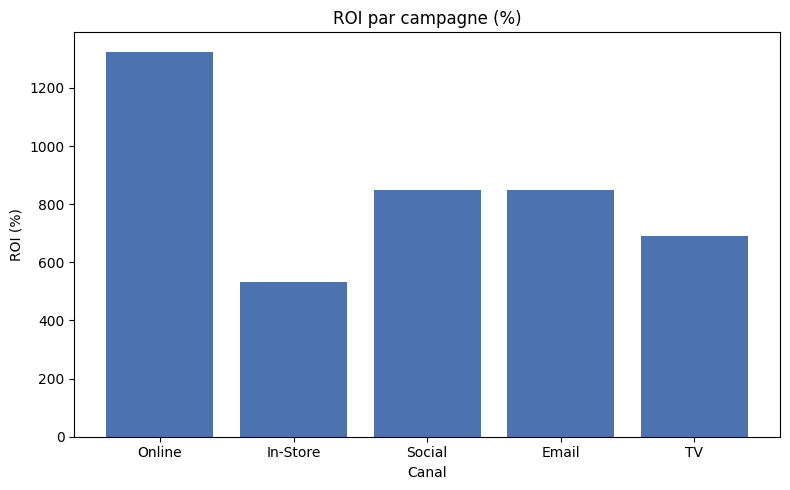

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(kpis["Channel"], kpis["ROI (%)"], color="#4C72B0")
plt.title("ROI par campagne (%)")
plt.xlabel("Canal")
plt.ylabel("ROI (%)")
plt.tight_layout()
plt.savefig("../../figures/m5_roi_par_canal.png", dpi=150)
plt.show()

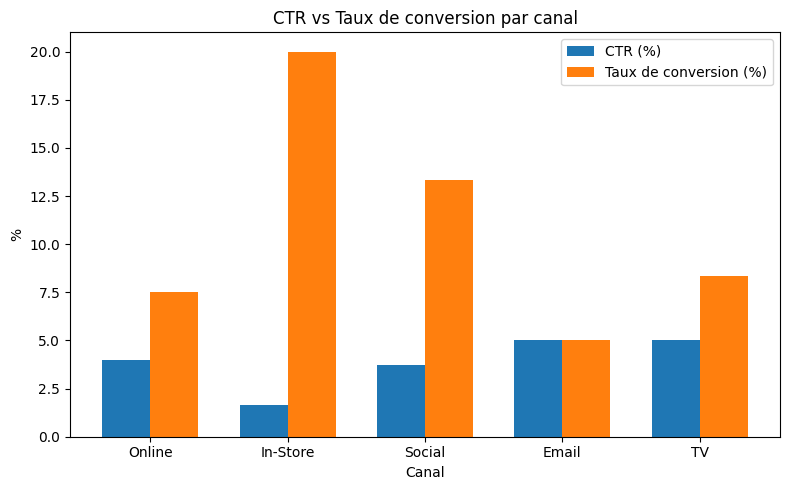

In [5]:
x = range(len(kpis))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], kpis["CTR (%)"], width, label="CTR (%)")
plt.bar([i + width/2 for i in x], kpis["Taux_Conversion (%)"], width, label="Taux de conversion (%)")
plt.xticks(list(x), kpis["Channel"])
plt.title("CTR vs Taux de conversion par canal")
plt.xlabel("Canal")
plt.ylabel("%")
plt.legend()
plt.tight_layout()
plt.savefig("../../figures/m5_ctr_vs_conversion.png", dpi=150)
plt.show()

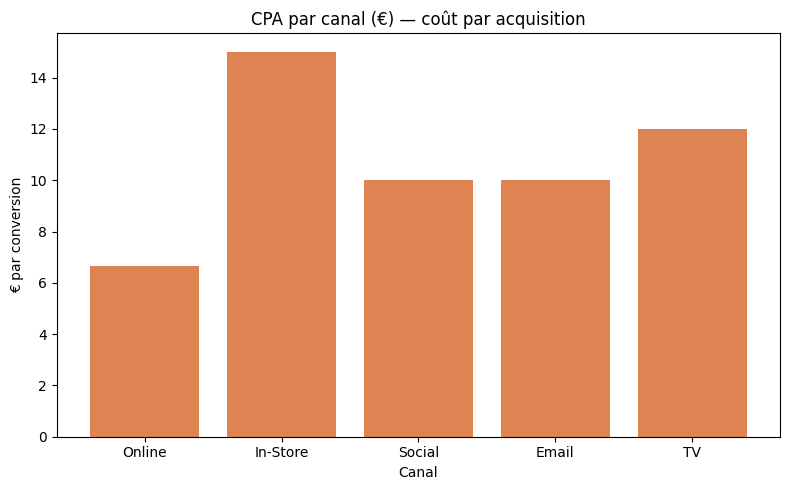

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(kpis["Channel"], kpis["CPA (€)"], color="#DD8452")
plt.title("CPA par canal (€) — coût par acquisition")
plt.xlabel("Canal")
plt.ylabel("€ par conversion")
plt.tight_layout()
plt.savefig("../../figures/m5_cpa_par_canal.png", dpi=150)
plt.show()

## 5. Export des KPIs en CSV (livraison à Toky et Lalatiana)

In [7]:
kpis.to_csv("kpis_campagnes_m5.csv", index=False)
print("Fichier exporté : kpis_campagnes_m5.csv")

Fichier exporté : kpis_campagnes_m5.csv


## 6. Conclusions pour le PowerPoint

- Canal le plus rentable : **Online** (ROI le plus élevé, CPA le plus bas)
- Canal à surveiller : **Email** (CTR correct mais conversion faible → revoir le ciblage ou le message)
- Canal à fort volume mais rentabilité moyenne : **TV** (gros budget, ROI correct sans être le meilleur)
- Recommandation : réallouer une partie du budget TV vers Online/Social pour améliorer le ROI global.